# Data analisys

Before developing regression models, analysing our data may reveal important information. With the acquired knowledge, we may be able to detect problems and quirks in our data, and deal with them properly.

## Setup

### Library loading

In [ ]:
import pandas as pd
import math
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from scipy import stats
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, PowerTransformer

### Data loading

In [2]:
df = pd.read_parquet("data/windsat_2017")

## Basic structure

Let's validate the dataset before any advanced analysis.

### Shape

In [13]:
df.shape

(13225757, 48)

We can see we have a very substantial amount of data.

### Variables

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13225757 entries, 0 to 13225756
Data columns (total 48 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   latitude_grid                float32
 1   longitude_grid               float32
 2   surtep_ERA5                  float32
 3   fwns                         float32
 4   Tmn                          float32
 5   PWV                          float32
 6   VOD                          float32
 7   vsm                          float32
 8   VPD                          float32
 9   ref_land_emis_de_lannoy_K_h  float64
 10  ref_land_emis_de_lannoy_K_v  float64
 11  tbtoa19V                     float32
 12  tbtoa19H                     float32
 13  tbtoa37V                     float32
 14  tbtoa37H                     float32
 15  tran19V                      float32
 16  tran19H                      float32
 17  tran37V                      float32
 18  tran37H                      float32
 19

There are a lot of variables in the dataset. It is possible not all of these are essential to our project.

### Simple statistics

In [16]:
df.describe(include="all")

,latitude_grid,longitude_grid,surtep_ERA5,fwns,Tmn,PWV,VOD,vsm,VPD,ref_land_emis_de_lannoy_K_h,...,emiss37V_de_lannoy,denominator,term_1,term_2,fwns_calculated,clase,porcentaje clase,sm_bin,vod_bin,day
count,1.322576e+07,1.322576e+07,1.322576e+07,1.322576e+07,1.322576e+07,1.322576e+07,1.322576e+07,1.322576e+07,1.322576e+07,1.322576e+07,...,1.322576e+07,1.322576e+07,1.322576e+07,1.322576e+07,1.322576e+07,1.322576e+07,1.322576e+07,1.322576e+07,1.322576e+07,1.322576e+07
mean,3.603915e+01,1.401255e+02,2.858118e+02,4.164822e-02,2.824166e+02,1.946441e+01,3.971513e-01,1.904094e-01,5.689056e-01,9.049120e-01,...,9.375858e-01,1.498645e+00,1.355949e+00,1.305607e+00,5.034241e-02,9.369298e+00,1.659104e+01,1.386219e+00,6.107769e+00,1.973433e+02
std,3.157395e+01,1.003987e+02,2.341554e+01,7.066451e-02,2.109371e+01,1.113898e+01,1.824952e-01,9.200675e-02,7.547768e-01,3.604884e-02,...,6.724536e-02,1.630431e-02,5.109201e-02,1.147912e-01,9.794633e-02,1.134503e+01,2.310372e+01,9.368460e-01,2.373384e+00,8.172960e+01
min,-5.587500e+01,1.250000e-01,2.396749e+02,0.000000e+00,2.602157e+02,0.000000e+00,0.000000e+00,2.500000e-02,0.000000e+00,7.615927e-01,...,5.567881e-01,1.418582e+00,1.145924e+00,4.555947e-01,-4.840022e-01,0.000000e+00,0.000000e+00,-1.000000e+00,0.000000e+00,1.000000e+00
25%,1.837500e+01,5.412500e+01,2.793567e+02,0.000000e+00,2.752077e+02,1.194889e+01,2.640085e-01,1.248152e-01,2.826200e-02,8.899351e-01,...,9.271837e-01,1.493521e+00,1.337573e+00,1.254467e+00,-5.330032e-03,0.000000e+00,0.000000e+00,1.000000e+00,5.000000e+00,1.490000e+02
50%,4.737500e+01,1.136250e+02,2.861123e+02,1.280200e-02,2.811289e+02,1.728142e+01,3.935674e-01,2.031098e-01,2.677113e-01,9.161988e-01,...,9.489298e-01,1.496426e+00,1.368915e+00,1.337943e+00,1.924895e-02,0.000000e+00,6.000000e+00,2.000000e+00,6.000000e+00,2.010000e+02
75%,6.162500e+01,2.421250e+02,2.925476e+02,4.747691e-02,2.900103e+02,2.413174e+01,5.313323e-01,2.538548e-01,8.357491e-01,9.329485e-01,...,9.623111e-01,1.500800e+00,1.387827e+00,1.384879e+00,7.166362e-02,2.200000e+01,2.400000e+01,2.000000e+00,8.000000e+00,2.570000e+02
max,8.237500e+01,3.598750e+02,3.131768e+02,8.460522e-01,3.111082e+02,8.000000e+01,9.985774e-01,6.000000e-01,6.695256e+00,9.457885e-01,...,1.166487e+00,1.684472e+00,1.434450e+00,1.809225e+00,8.367879e-01,3.300000e+01,1.000000e+02,4.000000e+00,1.000000e+01,3.650000e+02


Although we'll later visualize this data in a much better way, this helps us validate the data.

### Missing values

In [17]:
df.isna().mean().sort_values(ascending=False)

latitude_grid                  0.0
longitude_grid                 0.0
tbup37H                        0.0
tbboa_1st_order19V             0.0
tbboa_1st_order19H             0.0
tbboa_1st_order37V             0.0
tbboa_1st_order37H             0.0
tbboa_de_lannoy19V             0.0
tbboa_de_lannoy19H             0.0
tbboa_de_lannoy37V             0.0
tbboa_de_lannoy37H             0.0
emiss19H_de_lannoy             0.0
emiss19V_de_lannoy             0.0
emiss37H_de_lannoy             0.0
emiss37V_de_lannoy             0.0
denominator                    0.0
term_1                         0.0
term_2                         0.0
fwns_calculated                0.0
clase                          0.0
porcentaje clase               0.0
sm_bin                         0.0
vod_bin                        0.0
tbup37V                        0.0
tbup19H                        0.0
tbup19V                        0.0
tbtoa19V                       0.0
surtep_ERA5                    0.0
fwns                

Thankfully, we managed the data preprocessing well enough so that we don't have to deal with missing data now.

## Univariate statistical analysis

We will now check the individual structure of most variables through histograms.

### LPDR variables

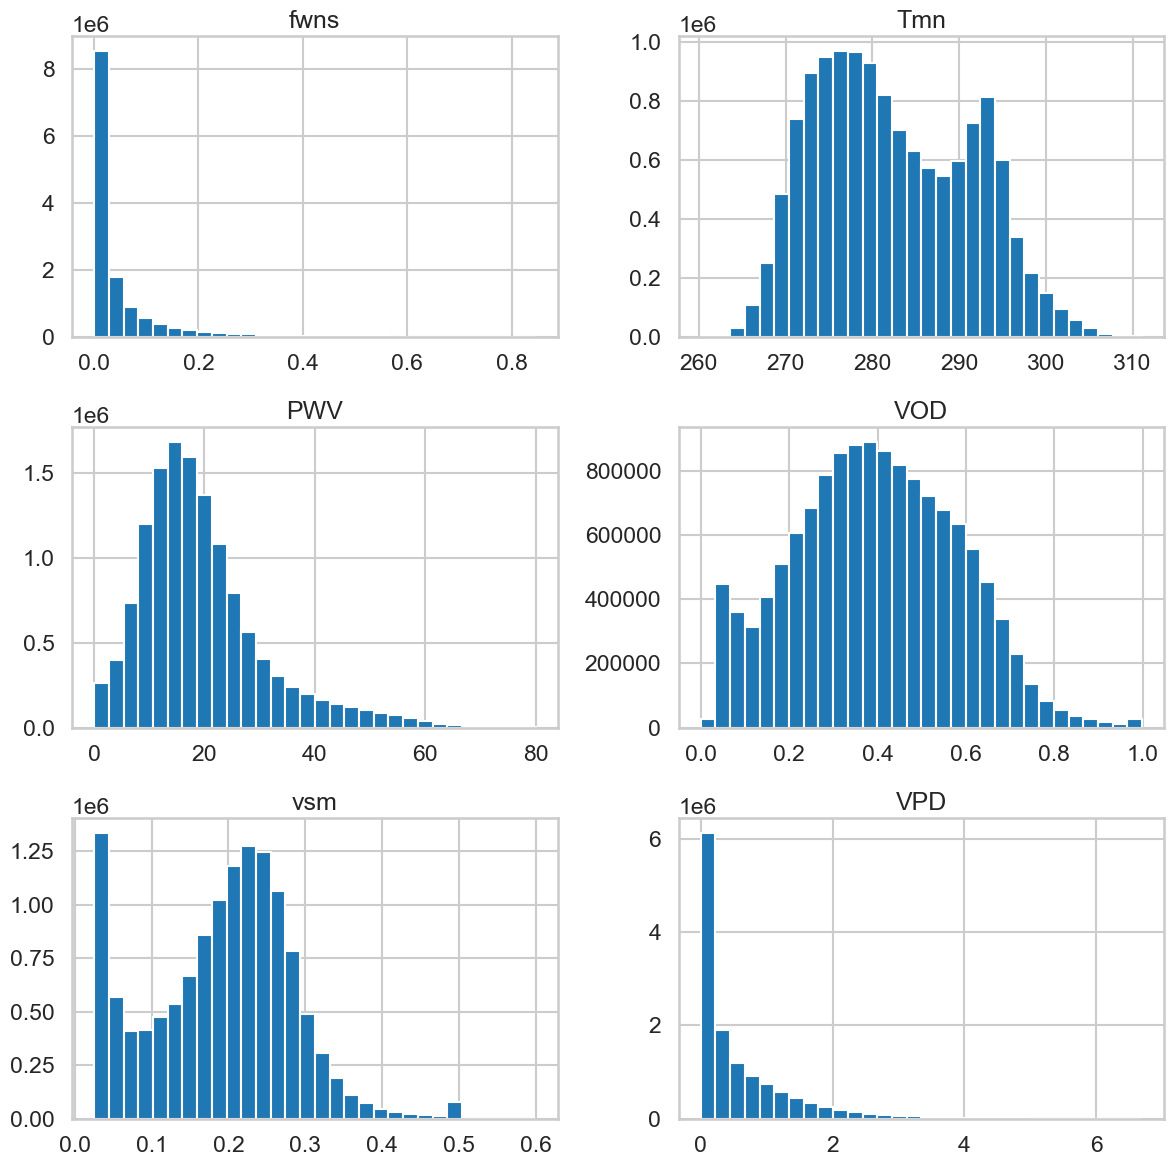

In [23]:
df_lpdr = df[['fwns', 'Tmn', 'PWV', 'VOD', 'vsm', 'VPD']]
df_lpdr.hist(bins=30, figsize=(12, 12))
plt.tight_layout()
plt.show()

We now know the distribution of our target variable, `fwns`. We see it is biased towards zero, with a decaying trend after that. Maybe a transformation would be in order.

### WINDSAT variables

We'll only visualize the 19V variables since most of the frequencies and polarizations follow similar distributions.

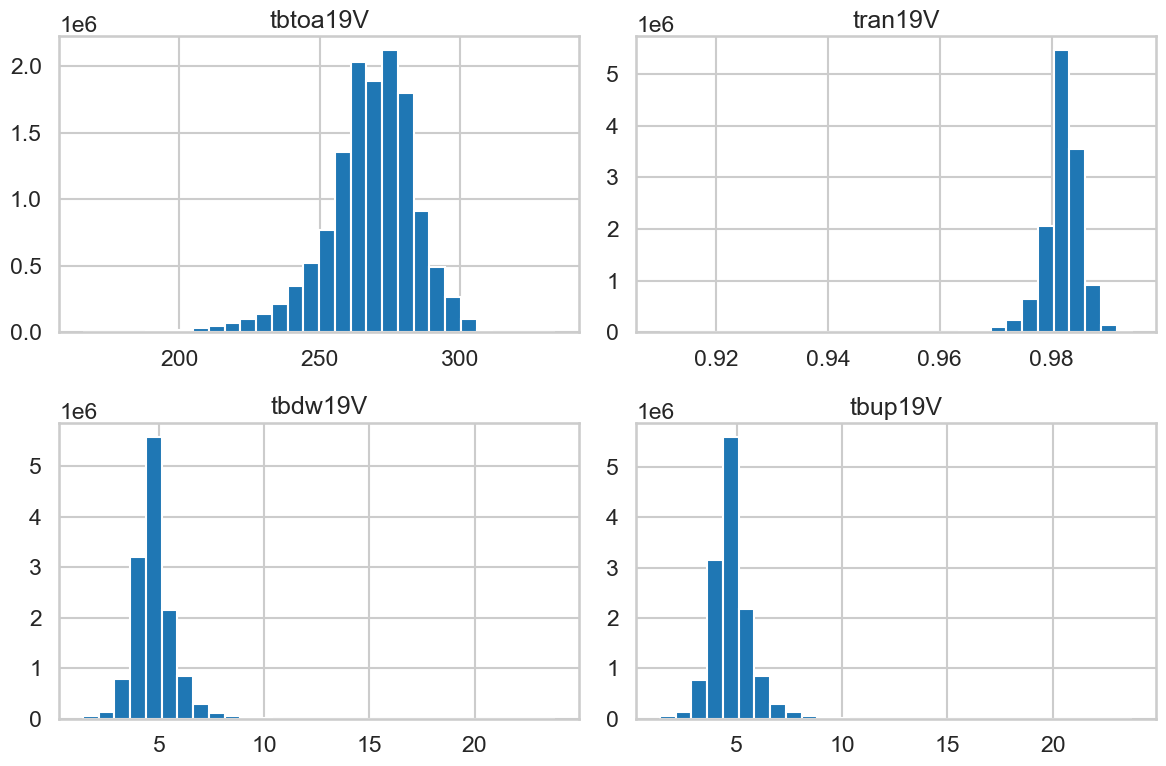

In [21]:
df_windsat = df[['tbtoa19V', 'tran19V', 'tbdw19V', 'tbup19V']]
df_windsat.hist(bins=30, figsize=(12, 8))
plt.tight_layout()
plt.show()

### Other variables

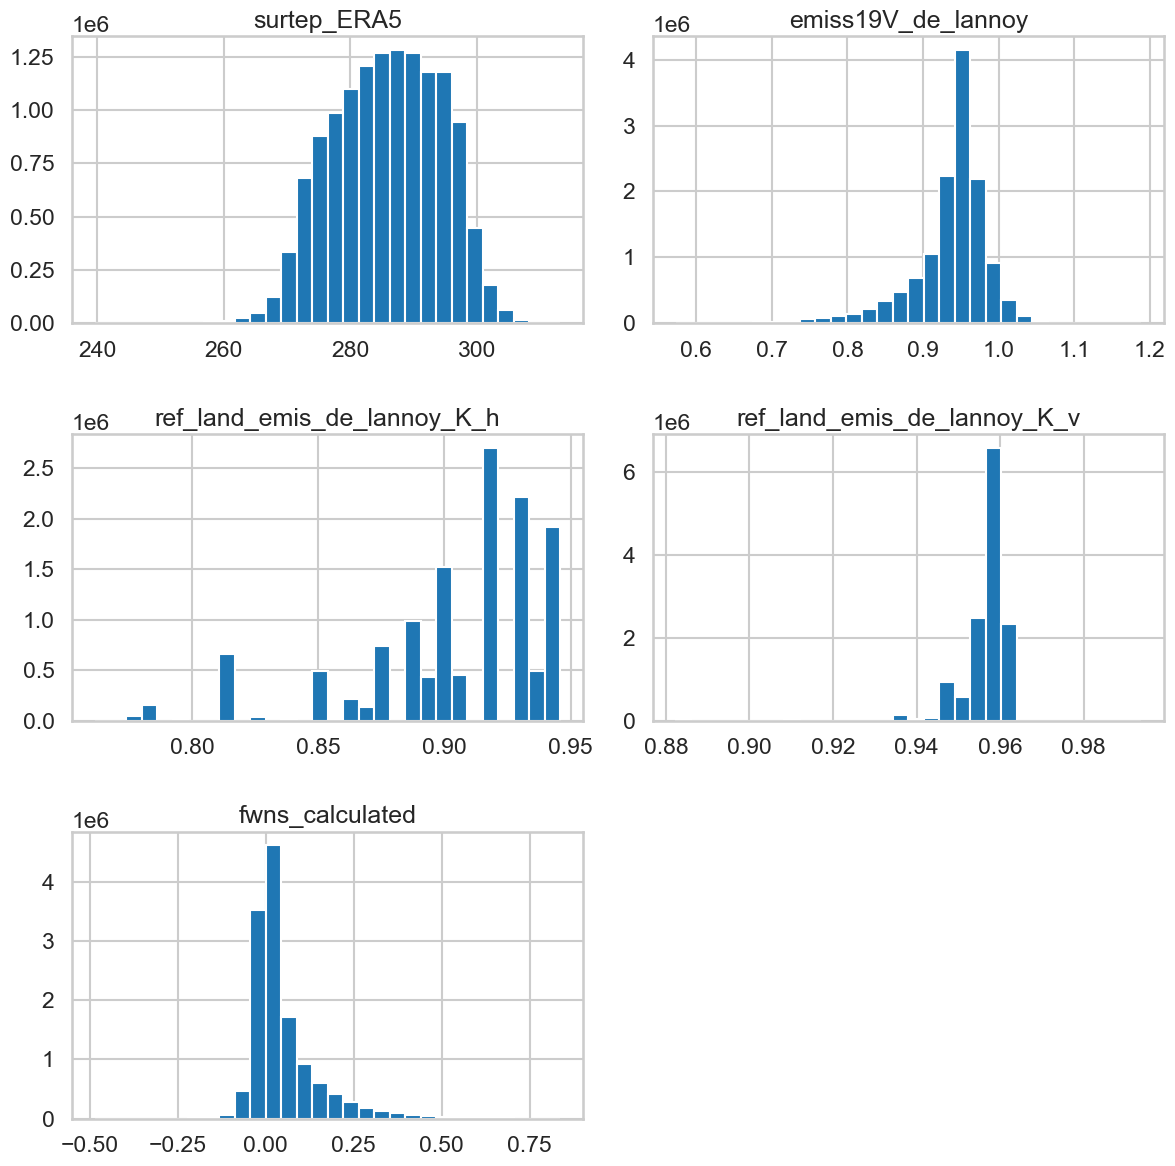

In [28]:
df_other = df[['surtep_ERA5', 'emiss19V_de_lannoy', 'ref_land_emis_de_lannoy_K_h', 'ref_land_emis_de_lannoy_K_v', 'fwns_calculated']]
df_other.hist(bins=30, figsize=(12, 12))
plt.tight_layout()
plt.show()

### Focusing on fwns

Since fwns is our target variable, it deserves its own analysis.

As we can see in its distribution, it's heaviliy skewed towards zero. Let's test if we can correct this with a logarithmic transformation.

In [3]:
# Remove zeros (and any non-positive values just to be safe)
print("Total zeroes:", len(df[df['fwns'] == 0]))
print("Zero percentage:", len(df[df['fwns'] == 0]) / len(df) * 100)
x_pos = df['fwns'][df['fwns'] > 0]

Total zeroes: 4260484
Zero percentage: 32.21353605695311


Original skewness: 3.2243538
Skewness after removing zeros: 2.723616


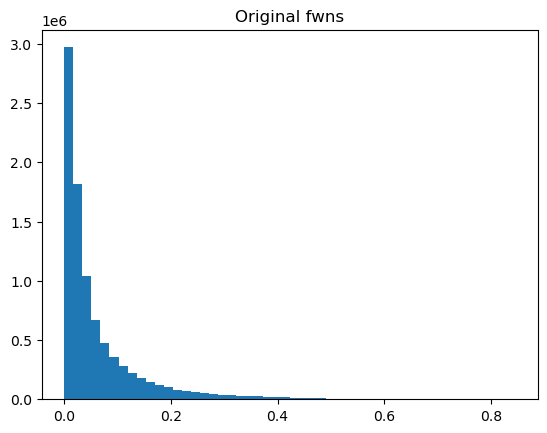

In [4]:
print("Original skewness:", stats.skew(df['fwns']))
print("Skewness after removing zeros:", stats.skew(x_pos))

plt.figure()
plt.hist(x_pos, bins=50)
plt.title("Original fwns")
plt.show()

Log1p skewness: 2.3660111


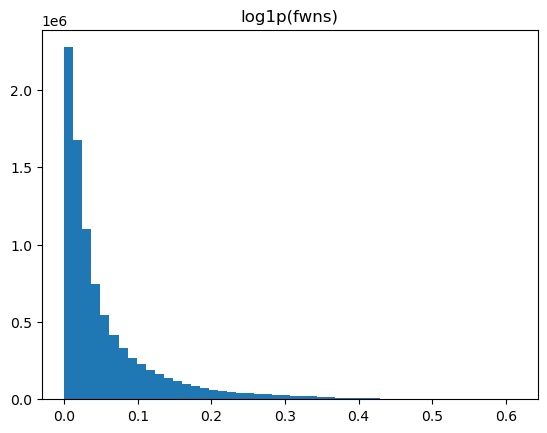

In [ ]:
x_log = np.log1p(x_pos)

print("Log1p skewness:", stats.skew(x_log))

plt.figure()
plt.hist(x_log, bins=50)
plt.title("log1p transformation fwns")
plt.show()

Log1p skewness: -0.67187505201733


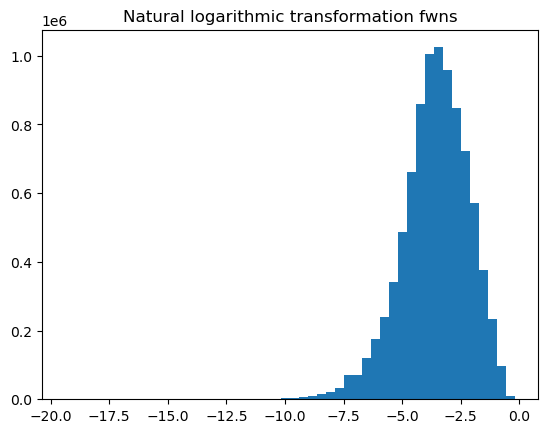

In [ ]:
x_log_base = x_pos.apply(lambda x: math.log(x))

print("Log1p skewness:", stats.skew(x_log_base))

plt.figure()
plt.hist(x_log_base, bins=50) 
plt.title("Natural logarithmic transformation fwns")
plt.show()

Box-Cox lambda: 0.1393834598773829
Box-Cox skewness: -0.004095802665191134


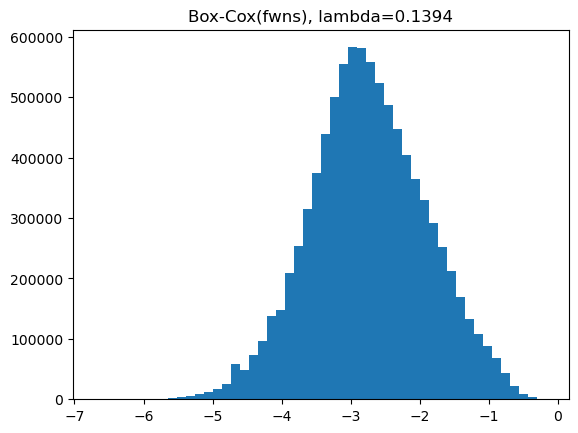

In [17]:
x_boxcox, lambda_bc = stats.boxcox(x_pos)

print("Box-Cox lambda:", lambda_bc)
print("Box-Cox skewness:", stats.skew(x_boxcox))

plt.figure()
plt.hist(x_boxcox, bins=50)
plt.title(f"Box-Cox(fwns), lambda={lambda_bc:.4f}")
plt.show()

Yeo-Johnson lambda: -12.369011
Yeo-Johnson skewness: 0.59300923


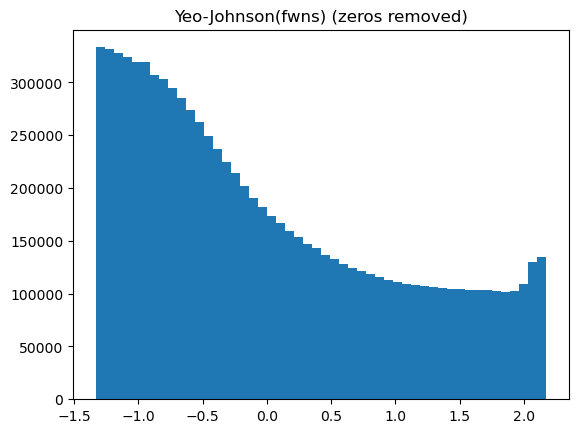

In [18]:
pt = PowerTransformer(method='yeo-johnson')

x_yj = pt.fit_transform(x_pos.values.reshape(-1, 1)).flatten()

print("Yeo-Johnson lambda:", pt.lambdas_[0])
print("Yeo-Johnson skewness:", stats.skew(x_yj))

plt.figure()
plt.hist(x_yj, bins=50)
plt.title("Yeo-Johnson(fwns) (zeros removed)")
plt.show()

Yeo-Johnson skewness: 0.99227816


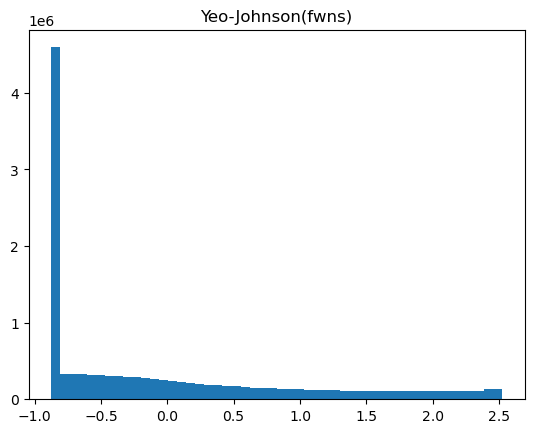

In [ ]:
pt = PowerTransformer(method='yeo-johnson')
x_yj = pt.fit_transform(x_pos.values.reshape(-1,1)).flatten()

print("Yeo-Johnson skewness:", stats.skew(x_yj))

plt.figure()
plt.hist(x_yj, bins=50)
plt.title("Yeo-Johnson(fwns)")
plt.show()

In [ ]:
fwns_log = np.log1p(df['fwns'])

fwns_box = stats.boxcox(df['fwns'] + 1e-6)

## Multivariate analysis

With as many as 47 variables in a dataset, it is imperative that we study their relation. With some luck, we may be able to remove a decent amount of them, speeding the training process.

### Correlation matrix

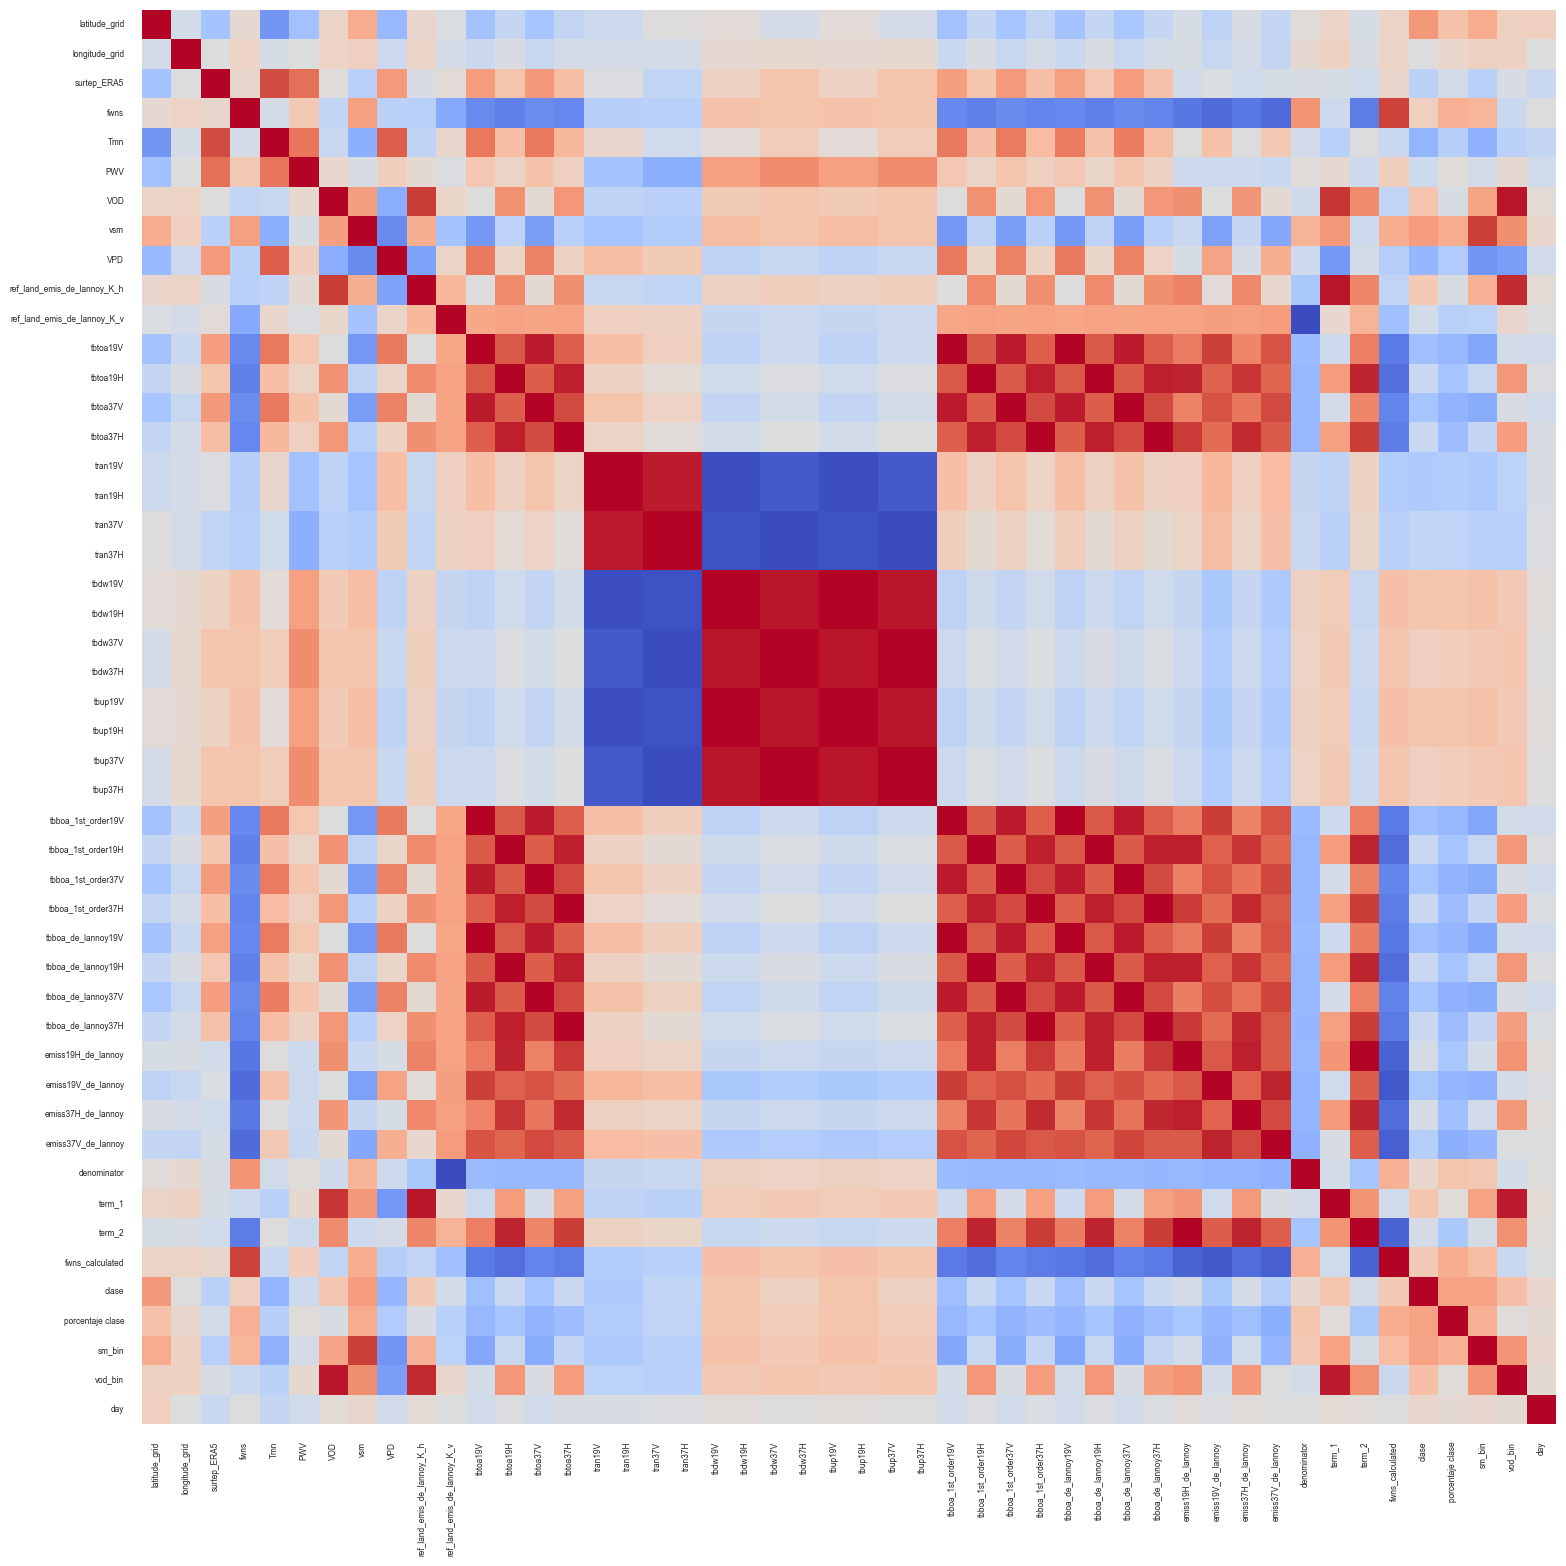

In [ ]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(16, 16))

ax = sns.heatmap(
    corr,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    cbar=False
)

# Force all ticks
ax.set_xticks(np.arange(len(corr.columns)) + 0.5)
ax.set_yticks(np.arange(len(corr.columns)) + 0.5)

ax.set_xticklabels(corr.columns, rotation=90, fontsize=6)
ax.set_yticklabels(corr.columns, rotation=0, fontsize=6)

plt.tight_layout()
plt.show()

There are clearly many related variables, but those existing between `tran`, `tbdw` and `tbup` are telling.

### Target correlation

In [ ]:
corr['fwns'].sort_values(ascending=False)

fwns                           1.000000
fwns_calculated                0.855435
denominator                    0.531121
vsm                            0.463293
porcentaje clase               0.379586
sm_bin                         0.346232
tbup19V                        0.262974
tbup19H                        0.262974
tbdw19V                        0.262965
tbdw19H                        0.262965
tbup37H                        0.245943
tbup37V                        0.245943
tbdw37H                        0.245924
tbdw37V                        0.245924
PWV                            0.211043
clase                          0.163359
longitude_grid                 0.132156
surtep_ERA5                    0.086078
latitude_grid                  0.064189
day                            0.005567
Tmn                           -0.065733
term_1                        -0.113530
vod_bin                       -0.135155
VOD                           -0.182565
VPD                           -0.228216


As was to be expected, the `fwns` estimated through the physical formula is the most correlated variable, but some others also reveal close ties.

## Machine learning oriented analysis

Let's check specific points in the structure of the dataset that could tell us better ways of training models.

### Scaling needs

In [39]:
df.max() - df.min()

latitude_grid                  138.250000
longitude_grid                 359.750000
surtep_ERA5                     73.501892
fwns                             0.846052
Tmn                             50.892456
PWV                             80.000000
VOD                              0.998577
vsm                              0.575000
VPD                              6.695256
ref_land_emis_de_lannoy_K_h      0.184196
ref_land_emis_de_lannoy_K_v      0.111272
tbtoa19V                       168.279999
tbtoa19H                       238.077515
tbtoa37V                       163.837479
tbtoa37H                       231.187500
tran19V                          0.084570
tran19H                          0.084570
tran37V                          0.171619
tran37H                          0.171619
tbdw19V                         22.487835
tbdw19H                         22.487835
tbdw37V                         45.597780
tbdw37H                         45.597780
tbup19V                         22

We can see that even though `fwns` has really small consistent values, other ones like surtep_ERA5 or tbtoa have extremely large values. We may need to scale this features down or outright remove them to improve our training.

### Dimensionality study

In [41]:
numeric_df = df.select_dtypes(include='number')

scaler = StandardScaler()
X_scaled = scaler.fit_transform(numeric_df)

In [42]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

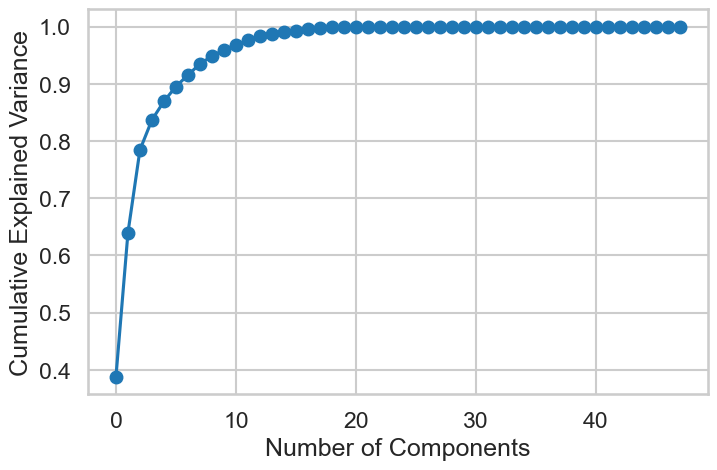

In [43]:
explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

plt.figure(figsize=(8,5))
plt.plot(cumulative, marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.grid(True)
plt.show()

In [45]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(len(numeric_df.columns))],
    index=numeric_df.columns
)

loadings[['PC1','PC2','PC3']].sort_values('PC1', ascending=False)

,PC1,PC2,PC3
emiss19V_de_lannoy,0.207997,0.012028,0.041154
emiss37V_de_lannoy,0.207120,0.021070,0.017265
tbboa_de_lannoy19V,0.206846,0.050155,0.138650
tbboa_de_lannoy37V,0.206688,0.061800,0.127242
tbboa_1st_order19V,0.206099,0.051522,0.140539
tbtoa19V,0.205515,0.052198,0.142338
tbboa_1st_order37V,0.205285,0.064626,0.130503
tbtoa37V,0.204276,0.066059,0.133450
tbboa_de_lannoy37H,0.198629,0.123371,-0.068199
tbboa_de_lannoy19H,0.198516,0.122620,-0.086420


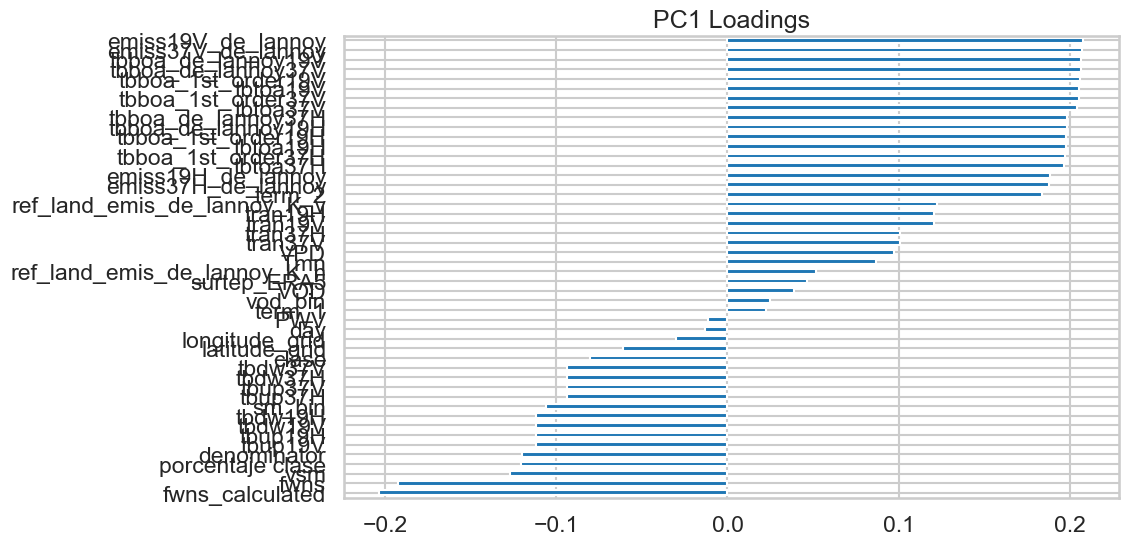

In [46]:
plt.figure(figsize=(10,6))
loadings['PC1'].sort_values().plot(kind='barh')
plt.title("PC1 Loadings")
plt.show()


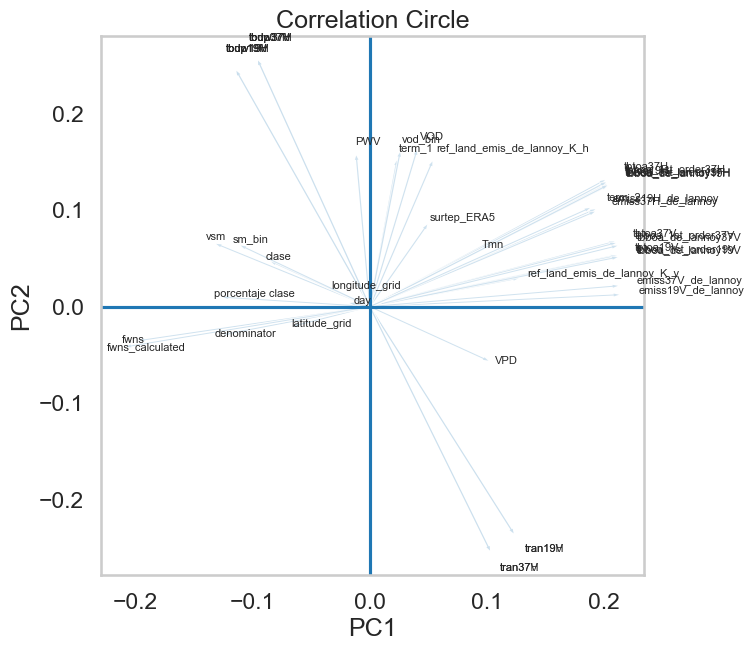

In [47]:
plt.figure(figsize=(7,7))

for i, var in enumerate(numeric_df.columns):
    plt.arrow(0, 0, 
              loadings.iloc[i,0], 
              loadings.iloc[i,1],
              alpha=0.7)
    plt.text(loadings.iloc[i,0]*1.1, 
             loadings.iloc[i,1]*1.1, 
             var, fontsize=8)

plt.axhline(0)
plt.axvline(0)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Correlation Circle")
plt.grid()
plt.show()


## Spatial and temporal structure

Each unit of data in our project corresponds to a single point in time and space. If we understand the interaction between our data and their spatial and temporal context, we will be able to better manage it and understand how it affects our final results.

In [3]:
df["location_id"] = (
    df["latitude_grid"].astype(str) + "_" +
    df["longitude_grid"].astype(str)
)

In [5]:
temporal_stats = (
    df.groupby("location_id")["fwns"]
      .agg(["mean", "std", "var", "count"])
      .reset_index()
)

temporal_stats["cv"] = temporal_stats["std"] / temporal_stats["mean"]  # coefficient of variation

In [6]:
temporal_stats = (
    df.groupby(["latitude_grid", "longitude_grid"])["fwns"]
      .agg(["mean", "std", "var", "count"])
      .reset_index()
)

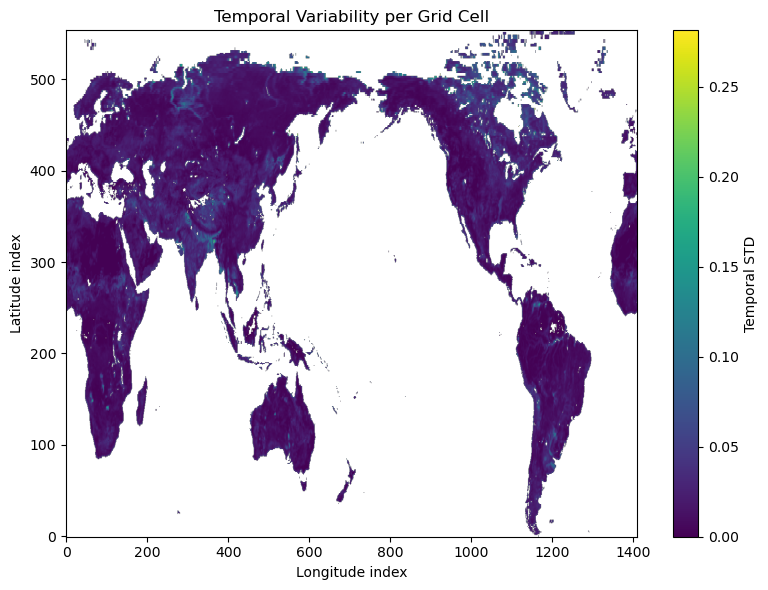

In [11]:
pivot_std = temporal_stats.pivot(
    index="latitude_grid",
    columns="longitude_grid",
    values="std"
)

plt.figure(figsize=(8,6))
plt.imshow(pivot_std, origin="lower", aspect="auto")
plt.colorbar(label="Temporal STD")
plt.title("Temporal Variability per Grid Cell")
plt.xlabel("Longitude index")
plt.ylabel("Latitude index")
plt.tight_layout()
plt.show()

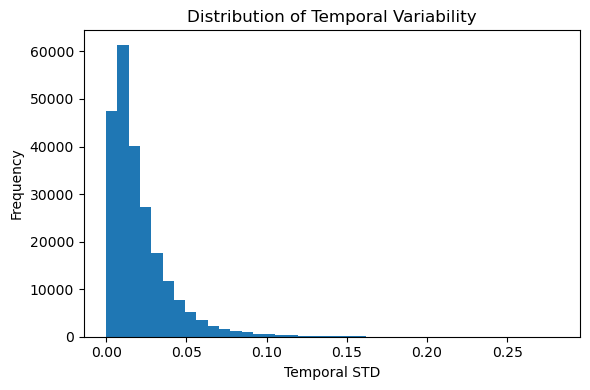

In [12]:
plt.figure(figsize=(6,4))
plt.hist(temporal_stats["std"], bins=40)
plt.xlabel("Temporal STD")
plt.ylabel("Frequency")
plt.title("Distribution of Temporal Variability")
plt.tight_layout()
plt.show()

In [14]:
spatial_stats = (
    df.groupby("day")["fwns"]
      .agg(["std", "mean"])
      .reset_index()
)

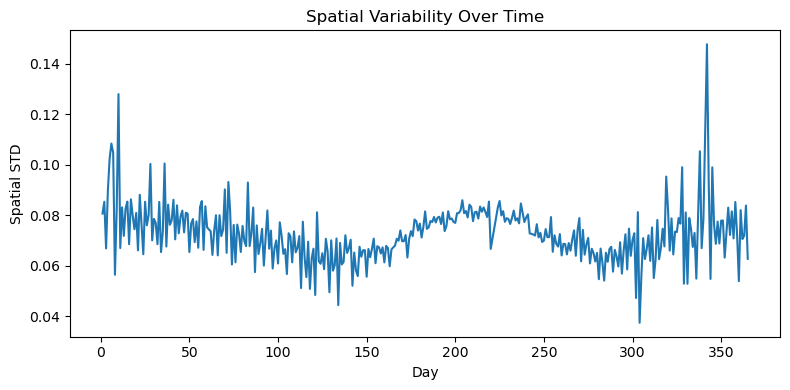

In [15]:
plt.figure(figsize=(8,4))
plt.plot(spatial_stats["day"], spatial_stats["std"])
plt.xlabel("Day")
plt.ylabel("Spatial STD")
plt.title("Spatial Variability Over Time")
plt.tight_layout()
plt.show()

In [25]:
def compute_spatial_difference(group):
    pivot = group.pivot(
        index="latitude_grid",
        columns="longitude_grid",
        values="fwns"
    )
    
    rolling_lat = pivot.rolling(
        window=5, center=True, min_periods=1
    ).mean()
    
    rolling_lon = (
        rolling_lat.T
        .rolling(window=5, center=True, min_periods=1)
        .mean()
        .T
    )
    
    spatial_diff = (pivot - rolling_lon).stack()
    
    group = group.set_index(
        ["latitude_grid", "longitude_grid"]
    )
    
    group["spatial_diff"] = spatial_diff
    
    return group.reset_index()

df_spatial = (
    df.groupby("day")
      .apply(compute_spatial_difference, include_groups=False)
      .reset_index(drop=True)
)

In [26]:
local_spatial_var = (
    df_spatial.groupby(["latitude_grid","longitude_grid"])["spatial_diff"]
              .std()
              .reset_index()
)

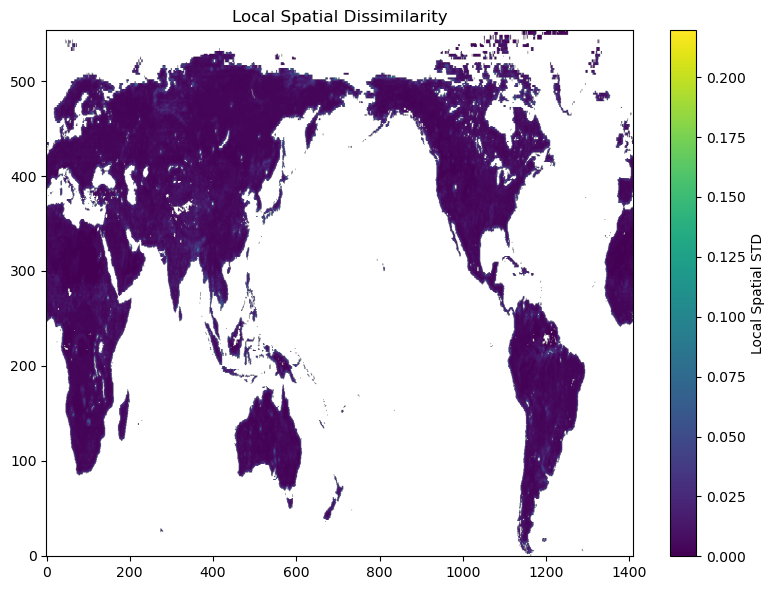

In [27]:
pivot_spatial = local_spatial_var.pivot(
    index="latitude_grid",
    columns="longitude_grid",
    values="spatial_diff"
)

plt.figure(figsize=(8,6))
plt.imshow(pivot_spatial, origin="lower", aspect="auto")
plt.colorbar(label="Local Spatial STD")
plt.title("Local Spatial Dissimilarity")
plt.tight_layout()
plt.show()

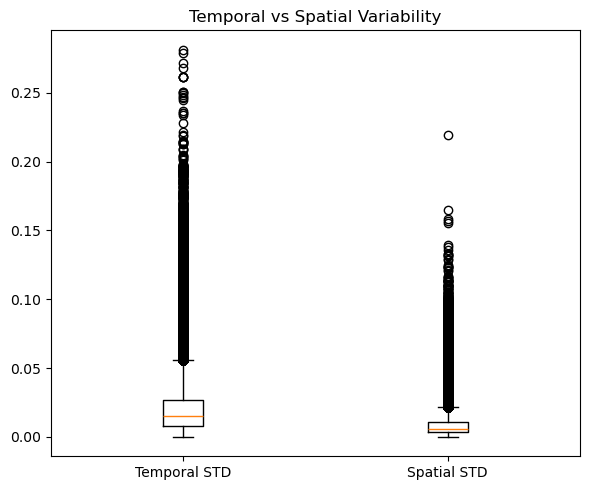

In [29]:
plt.figure(figsize=(6,5))
plt.boxplot([
    temporal_stats["std"].dropna(),
    local_spatial_var["spatial_diff"].dropna()
],
tick_labels=["Temporal STD", "Spatial STD"])

plt.title("Temporal vs Spatial Variability")
plt.tight_layout()
plt.show()

In [30]:
lat_cut = df["latitude_grid"].median()
lon_cut = df["longitude_grid"].median()

def assign_quadrant(row):
    if row["latitude_grid"] >= lat_cut and row["longitude_grid"] >= lon_cut:
        return "NE"
    elif row["latitude_grid"] >= lat_cut and row["longitude_grid"] < lon_cut:
        return "NW"
    elif row["latitude_grid"] < lat_cut and row["longitude_grid"] >= lon_cut:
        return "SE"
    else:
        return "SW"

df["quadrant"] = df.apply(assign_quadrant, axis=1)

<Figure size 700x500 with 0 Axes>

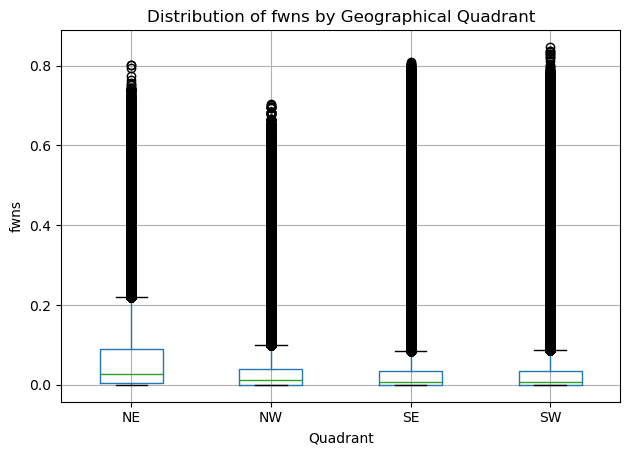

In [31]:
plt.figure(figsize=(7,5))
df.boxplot(column="fwns", by="quadrant")
plt.title("Distribution of fwns by Geographical Quadrant")
plt.suptitle("")
plt.xlabel("Quadrant")
plt.ylabel("fwns")
plt.tight_layout()
plt.show()

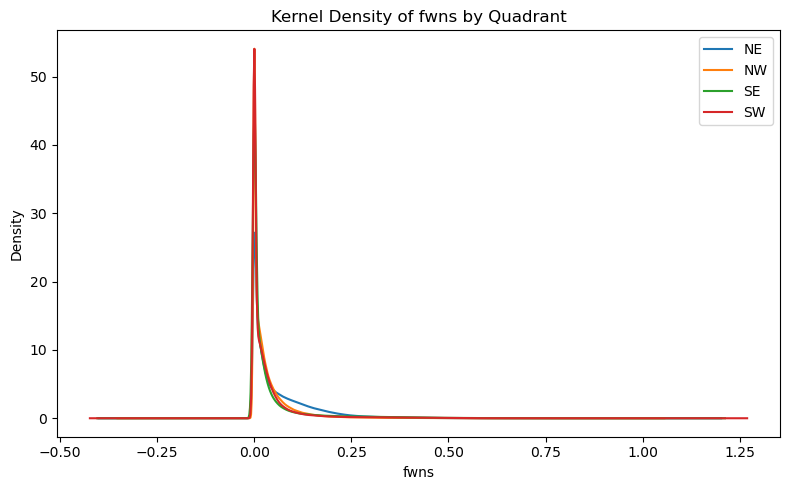

In [32]:
plt.figure(figsize=(8,5))

for q in ["NE","NW","SE","SW"]:
    subset = df[df["quadrant"] == q]["fwns"]
    subset.plot(kind="kde", label=q)

plt.legend()
plt.title("Kernel Density of fwns by Quadrant")
plt.xlabel("fwns")
plt.tight_layout()
plt.show()

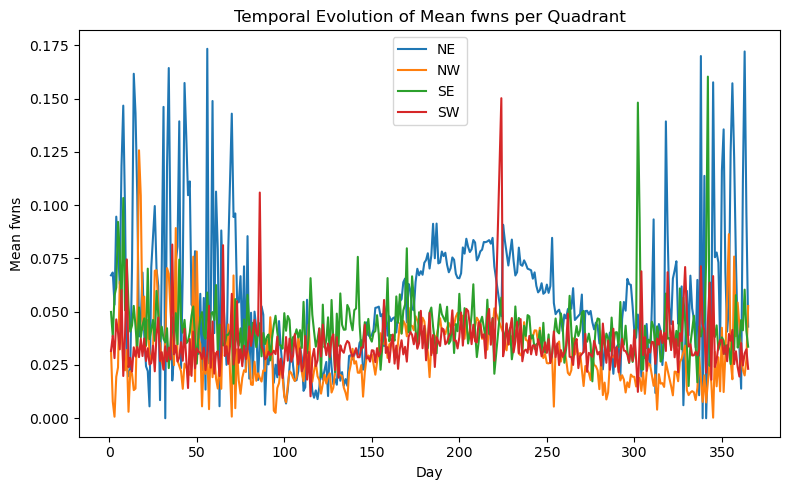

In [33]:
quad_time = (
    df.groupby(["day","quadrant"])["fwns"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(8,5))

for q in ["NE","NW","SE","SW"]:
    subset = quad_time[quad_time["quadrant"] == q]
    plt.plot(subset["day"], subset["fwns"], label=q)

plt.legend()
plt.title("Temporal Evolution of Mean fwns per Quadrant")
plt.xlabel("Day")
plt.ylabel("Mean fwns")
plt.tight_layout()
plt.show()

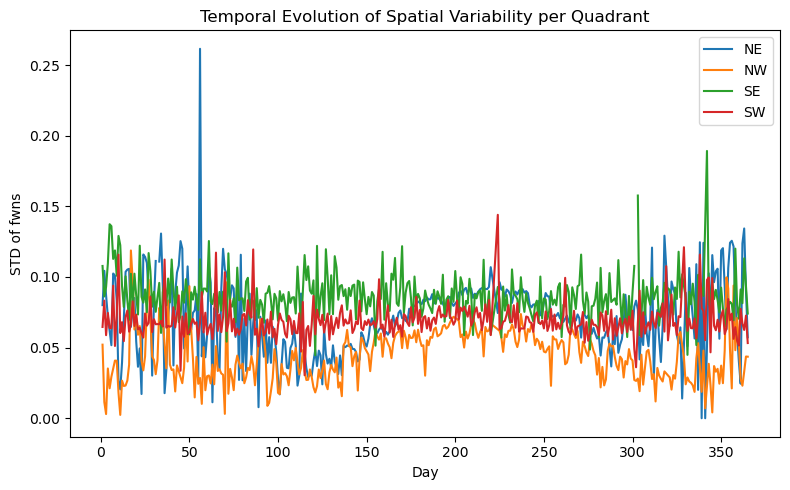

In [34]:
quad_time_std = (
    df.groupby(["day","quadrant"])["fwns"]
      .std()
      .reset_index()
)

plt.figure(figsize=(8,5))

for q in ["NE","NW","SE","SW"]:
    subset = quad_time_std[quad_time_std["quadrant"] == q]
    plt.plot(subset["day"], subset["fwns"], label=q)

plt.legend()
plt.title("Temporal Evolution of Spatial Variability per Quadrant")
plt.xlabel("Day")
plt.ylabel("STD of fwns")
plt.tight_layout()
plt.show()